In [93]:
# Import Libraries and Configure Matplotlib
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import re
import collections
from matplotlib import cm
from matplotlib import colors
from pycirclize import Circos
from tqdm import tqdm


In [94]:

# Initialize Circos with a single sector for nl43 ΔΔE
start_aa = 1  # Starting amino acid position
actual_length = 99
circos_length = actual_length +1
sectors = {"nl43 ΔΔE": actual_length}
circos = Circos(sectors, space=0, start=0, end=340)

# Get the sector
sector = circos.get_sector("nl43 ΔΔE")

# Add outer track for the main arc
track1 = sector.add_track((96, 98))
track1.rect(0, actual_length, fc="grey", ec="grey", lw=1.0)

# Add ticks and labels
major_ticks_pos = list(range(0, actual_length, 5))
major_ticks_labels = [str(i+1) if (i+1) % 5 == 1 else "" for i in major_ticks_pos]
all_ticks_pos = list(range(0, actual_length, 1))
all_ticks_labels = None

track1.xticks(major_ticks_pos, major_ticks_labels, label_size=10, tick_length=2,outer=False)
track1.xticks(all_ticks_pos, all_ticks_labels, label_size=8, tick_length=1,outer=False)
# Load and Parse data file
pairs = []
values_all = []



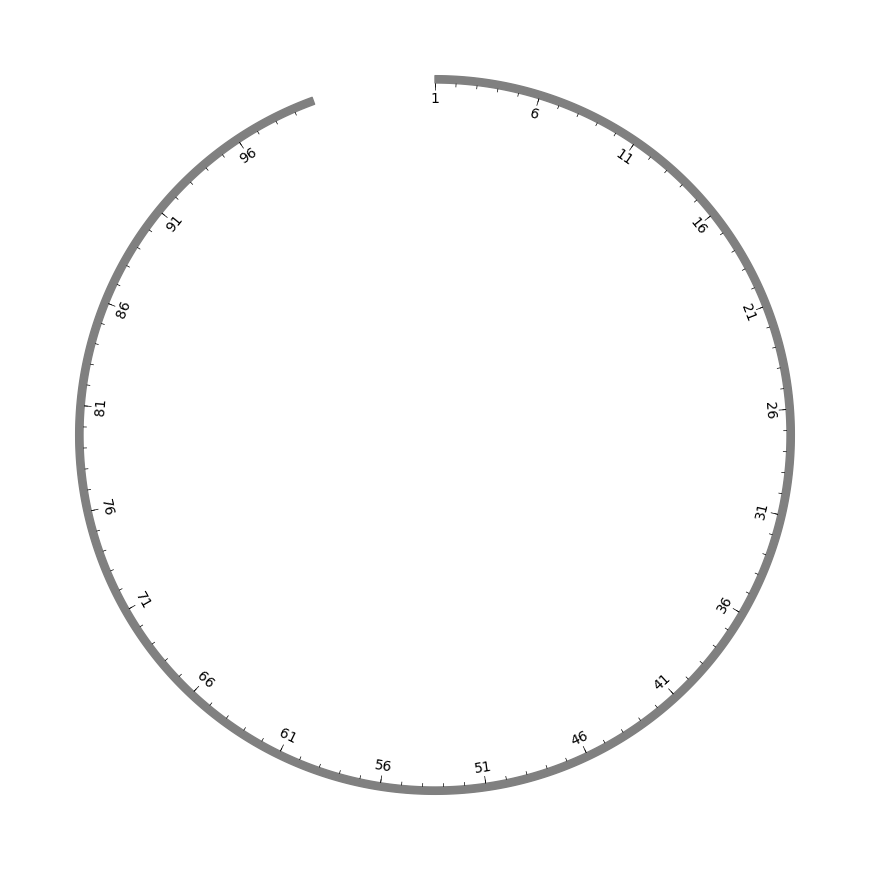

In [95]:
fig = circos.plotfig()
plt.show()

strictly follow the api of this exmple, for each position that has a mutaiton, annotate the specific drug and the drug resistant mutations it has:
    from pycirclize import Circos
from pycirclize.parser import Gff
from pycirclize.utils import load_prokaryote_example_file

gff_file = load_prokaryote_example_file("enterobacteria_phage.gff")
gff = Gff(gff_file)

seqid2size = gff.get_seqid2size()
space = 0 if len(seqid2size) == 1 else 2
circos = Circos(sectors=seqid2size, space=space)

seqid2features = gff.get_seqid2features(feature_type="CDS")
for sector in circos.sectors:
    track = sector.add_track((90, 100))
    track.axis(fc="#EEEEEE", ec="none")
    track.grid(2, color="black")

    features = seqid2features[sector.name]
    for feature in features:
        # Plot CDS feature
        if feature.location.strand == 1:
            track.genomic_features(feature, plotstyle="arrow", r_lim=(95, 100), fc="salmon")
        else:
            track.genomic_features(feature, plotstyle="arrow", r_lim=(90, 95), fc="skyblue")
        # Plot feature annotation label
        start, end = int(feature.location.start), int(feature.location.end)
        label_pos = (start + end) / 2
        label = feature.qualifiers.get("product", [""])[0]
        if label == "" or label.startswith("hypothetical"):
            continue
        track.annotate(label_pos, label, label_size=7)

fig = circos.plotfig()

use format: T66A/I/K drug: BIC, CAB, DTG, EVG, RAL

In [96]:
import glob
import pandas as pd

# Create dictionary for NRTI and NNRTI resistance mutations
# Read and merge from all drug_resistant*.tsv files

# Initialize the resistance_mutations dictionary structure
resistance_mutations = {
    "Drug_Resistant": {
        "positions": [],
        "consensus": [],
        "mutations": []
    }
}

# Find all drug_resistant*.tsv files
tsv_files = glob.glob('data/drug_resistant*.tsv')

# Read and merge all TSV files
all_drms = []
for file in tsv_files:
    try:
        df = pd.read_csv(file, sep='\t')
        # Rename columns to standard format if needed
        if 'PositionConsensus' in df.columns:
            df = df.rename(columns={'PositionConsensus': 'Position'})
        all_drms.append(df[['Position', 'Consensus', 'DRM']])
    except Exception as e:
        print(f"Error reading {file}: {e}")
        continue

# Combine all dataframes
if all_drms:
    combined_df = pd.concat(all_drms, ignore_index=True)
    
    # Group by position and consensus to collect all mutations
    grouped = combined_df.groupby(['Position', 'Consensus'])['DRM'].apply(lambda x: ''.join(sorted(set(x)))).reset_index()
    
    # Populate the resistance_mutations dictionary
    for _, row in grouped.iterrows():
        resistance_mutations["Drug_Resistant"]["positions"].append(int(row['Position']))
        resistance_mutations["Drug_Resistant"]["consensus"].append(row['Consensus'])
        resistance_mutations["Drug_Resistant"]["mutations"].append(row['DRM'])
else:
    print("No drug resistant TSV files found or readable")

print("Resistance Mutations Dictionary created:")
for category, data in resistance_mutations.items():
    print(f"\nCategory: {category}")
    print(f"Positions: {data['positions']}")
    print(f"Consensus: {data['consensus']}")

Resistance Mutations Dictionary created:

Category: Drug_Resistant
Positions: [10, 20, 23, 24, 30, 32, 33, 43, 46, 47, 48, 50, 53, 54, 58, 73, 74, 76, 82, 83, 84, 88, 89, 90]
Consensus: ['L', 'K', 'L', 'L', 'D', 'V', 'L', 'K', 'M', 'I', 'G', 'I', 'F', 'I', 'Q', 'G', 'T', 'L', 'V', 'N', 'I', 'N', 'L', 'L']


In [97]:
# Add annotation track for mutations
annotation_track = sector.add_track((90, 100))

# Annotate each mutation position
annotated_positions = set()  # Track annotations to avoid duplicates
for category in resistance_mutations.keys():
    for i, pos in enumerate(resistance_mutations[category]["positions"]):
        
        circos_pos = pos - start_aa  # Adjust position to start from start_aa
        consensus = resistance_mutations[category]["consensus"][i]

        # Ensure circos_pos is within the valid range of the sector
        if circos_pos < 0 or circos_pos >= sector.size:
            print(f"Skipping position {pos} as it is out of range for the sector.")
            continue

        # Create label with consensus and position
        label = f"{consensus}{pos}"

        # Check if this position has already been annotated
        if (consensus, pos) not in annotated_positions:
            annotation_track.annotate(circos_pos, label, label_size=13, shorten=100)
            annotated_positions.add((consensus, pos))

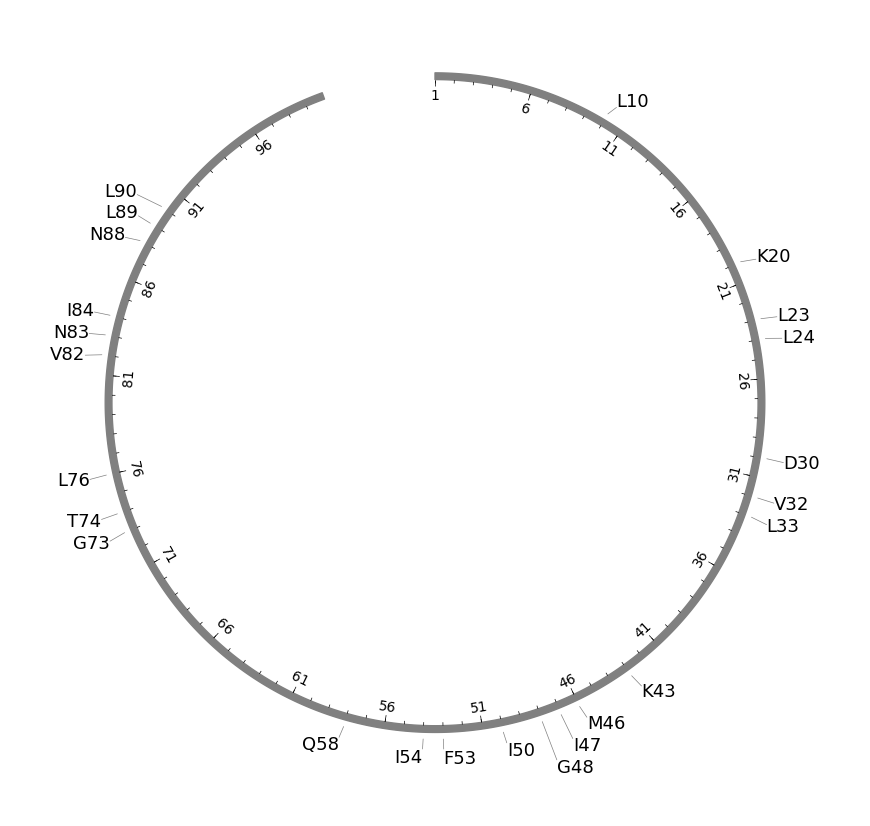

In [98]:
fig = circos.plotfig()
plt.show()

make a track that shows different segments with different colors as well as lablels: 1-50 as NTD, 50-212 as CCD, 212-end as CTD
add a tick track on top of this track, in each middle position, use tick label NTD, CCD and CTD like this: 
track1 = sector.add_track((98, 100))
track1.rect(0, 263, fc="grey", ec="grey", lw=1.0)

# Add ticks and labels
major_ticks_pos = list(range(0, 263, 10))
major_ticks_labels = [str(i+1) if (i+1) % 10 == 1 else "" for i in major_ticks_pos]
all_ticks_pos = list(range(0, 263, 1))
all_ticks_labels = None

track1.xticks(major_ticks_pos, major_ticks_labels, label_size=10)
track1.xticks(all_ticks_pos, all_ticks_labels, label_size=8)
# Load and Parse data file
pairs = []
values_all = []

read from in.uni4.npy, the file is in shape 263*4: 
[[1, 0, 0, 0],
 [0.0010070493444800377, 0.9989929795265198, 0, 0],
 [0.996834933757782, 0.0011509135365486145, 0.0010070493444800377, 0.0010070493444800377],
 [1, 0, 0, 0],
 [1, 0, 0, 0],
 ...]

 add a track with four grid each column on each position to display the heatmap. also include color grade bar 


read in from kn.her2.all, its in format: 
A1B-B2A 0.012168 -20.5323038958 -8.38054968975 -12.211337151
A1B-B2C -0.000907891 -16.4984526904 -8.38054968975 -8.17965538055
 first [0]column contains two mutations and location, second [1]column is the delta delta e for the two mutations 
 fourth [3]column is the single delta E for the first mutaiton, fifth[4] column is the single delta E for the second mutaiton

store the follwing two dictionarys: delta E for each position: 1: (should contain three values for three mutations (or you can use set operation on all the mutations with 1 and this will end up with only three values))
                                                                2: (should contain three values) 
                                                                3: so on
                                    delta delta Es for each two positions: []

In [99]:
# Initialize dictionaries to store delta E and delta delta E values
delta_e_per_position = collections.defaultdict(lambda: [0.0, 0.0, 0.0, 0.0])
delta_delta_e_per_pair = []

# Define mutation_map to map amino acids to indices
mutation_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}

# Read the file and process the data
with open('data/kn.her2.all') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        columns = re.split(r'[,\t\s]+', line)
        mutations = columns[0]
        ddE = float(columns[1])
        delta_e1 = float(columns[3])
        delta_e2 = float(columns[4])
        
        # Extract positions from the mutation string
        positions = [int(pos) for pos in re.findall(r'\d+', mutations)]
        if len(positions) != 2:
            continue
        
        pos1, pos2 = positions
        
        #detect the wildtype 'first' aa seuqnce, and put A' delta e into [0]....D's delta e into [3]
        # Store delta E values for each position
        # Detect the wildtype 'first' amino acid sequence
        wildtype_aa1 = mutations[0]  # Extract the first amino acid from the mutation string
        wildtype_aa2 = mutations.split('-')[1][0]  # Extract the first letter after '-'
        mutate_aa1 = mutations[mutations.index('-') - 1]  # Extract the one letter before '-'
        mutate_aa2 = mutations[-1]
        # print(f"Processing mutation: {mutations}, Positions: {pos1}, {pos2}, Wildtype AAs: {wildtype_aa1}, {wildtype_aa2}, Mutated AA1: {mutate_aa1}, Mutated AA2: {mutate_aa2}")
        # Map the wildtype amino acid to the corresponding index in the delta_e_per_position list
        if mutate_aa1 in mutation_map:
            delta_e_per_position[pos1][mutation_map[mutate_aa1]] = delta_e1
        if mutate_aa2 in mutation_map:
            delta_e_per_position[pos2][mutation_map[mutate_aa2]] = delta_e2
        
        # Store delta delta E values for each pair of positions
        delta_delta_e_per_pair.append((pos1, pos2, ddE))


print("Delta E per position:")
for pos, values in delta_e_per_position.items():
    print(f"Position {pos}: {values}")

print("\nDelta Delta E per pair:")
for pair in delta_delta_e_per_pair[:10]:  # Print first 10 pairs for brevity
    print(pair)

Delta E per position:
Position 1: [-7.65687820315361, 0.0, -15.270409390330315, -15.244200959801674]
Position 2: [-8.055814119055867, -11.32244774652645, 0.0, -8.569090587086976]
Position 3: [-7.9588273745030165, -8.571915650740266, 0.0, -8.155805517919362]
Position 4: [-7.901709549129009, -9.062162205576897, -5.582528863102198, 0.0]
Position 5: [-7.671862963587046, -8.509819394443184, -7.5506263598799706, 0.0]
Position 6: [-8.702947990968823, -10.011449309065938, -10.609377598389983, 0.0]
Position 7: [-8.150218181312084, -6.7850492196157575, 0.0, -6.993757659569383]
Position 8: [-7.00242667645216, -10.810621596872807, -15.089234918355942, 0.0]
Position 9: [-8.264814216643572, -11.578867871314287, 0.0, -15.075881361961365]
Position 10: [-4.653488149866462, -5.01730927452445, -3.001409363001585, 0.0]
Position 11: [-6.655691193416715, -8.730066085234284, -9.590635046362877, 0.0]
Position 12: [-4.187727555632591, -2.6436189003288746, -5.369526390917599, 0.0]
Position 13: [-8.3357884958386

save the delta_delta_e_per_pair into a tsv file of circos link plot format 

read in in.uni4.npy again, now for each row, get the second largest value index if its not 0, if second largest value is 0, index is None

now filter delta_e_per_position with the indecies second_largest_indices, generate the list of delta e values at delta_e_per_position if the its not None, if its None, the delta e at that position would be 0

now similar to this, but i not only want the second most sigificant. create a dictionary that has all positions as keys, alist as values, for each position, add the each delta_e_per_position value to the list if it is 1. not most frequent 2. the corrosponding amino acid's position's frequency in in.uni4.npy is >=0.00082

now add in a line track with the above filtered_delta_e_values, and color the areas like this code example:

from pycirclize import Circos
import numpy as np
np.random.seed(0)

sectors = {"A": 10, "B": 20, "C": 15}
circos = Circos(sectors, space=5)
for sector in circos.sectors:
    track = sector.add_track((80, 100), r_pad_ratio=0.1)
    track.axis()
    track.xticks_by_interval(1)
    vmin, vmax = 0, 10
    # Line between start-end two points
    track.line([track.start, track.end], [vmin, vmax], lw=1.5, ls="dotted")
    # Line of random value points
    x = np.linspace(track.start, track.end, int(track.size) * 5 + 1)
    y = np.random.randint(vmin, vmax, len(x))
    track.line(x, y)
fig = circos.plotfig()


In [100]:
import numpy as np
from collections import Counter

# Define the alphabet
alphabet = ['A', 'B', 'C', 'D']

# Read the sequences from the file
with open('data/pr.exper.reduce4.seq', 'r') as f:
    sequences = f.readlines()

# Remove any whitespace characters (e.g., newlines) from the sequences
sequences = [seq.strip() for seq in sequences]

# Initialize a list to store the frequency arrays
frequency_list = []

# Calculate the frequency for each position
sequence_length = len(sequences[0])  # Assume all sequences have the same length
sequence_count = len(sequences)
print(f"Total number of sequences: {sequence_count}")
for i in range(sequence_length):
    # Count the occurrences of each alphabet at the current position
    position_counts = Counter(seq[i] for seq in sequences)
    # Calculate the frequency for each alphabet
    frequencies = [position_counts[char] / sequence_count for char in alphabet]
    
    # Append the frequencies to the list
    frequency_list.append(frequencies)

# Convert the list to a NumPy array
frequency_array = np.array(frequency_list)

# Save the array to a .npy file
np.save('data/frequency.npy', frequency_array)

print("Frequency array saved to 'data/frequency.npy'")

Total number of sequences: 5710
Frequency array saved to 'data/frequency.npy'


In [101]:
# Read the data from the file again
data = np.load("data/frequency.npy")  # Shape: (263, 4)

# Get the second largest value index for each row
second_largest_indices = []
for row in data:
    sorted_indices = np.argsort(row)[::-1]  # Sort indices in descending order of values
    if row[sorted_indices[1]] > 0:  # Check if the second largest value is not 0
        second_largest_indices.append(sorted_indices[1])
    else:
        second_largest_indices.append(None)

# Print the result
print("Second largest value indices (or None if second largest is 0):")
print(second_largest_indices)

Second largest value indices (or None if second largest is 0):
[np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(1), np.int64(1), np.int64(3), np.int64(2), np.int64(2), np.int64(1), np.int64(3), np.int64(1), np.int64(2), np.int64(3), np.int64(3), np.int64(1), np.int64(3), np.int64(0), np.int64(1), np.int64(0), None, np.int64(0), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(2), np.int64(0), np.int64(1), np.int64(2), np.int64(0), None, np.int64(2), np.int64(3), np.int64(3), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(3), np.int64(1), np.int64(3), np.int64(3), np.int64(1), np.int64(3), np.int64(2), np.int64(0), np.int64(2), np.int64(2), np.int64(3), np.int64(0), np.int64(2), np.int64(3), np.int64(0), np.int64(1), np.int64(2), np.int64(0), np.int64(2), np.int64(1), np.int64(3), np.int64(1), n

In [102]:
filtered_delta_e_values = []

for pos, index in enumerate(second_largest_indices):
    if index is not None:
        # Retrieve the delta E value at the given position and index
        filtered_delta_e_values.append(delta_e_per_position[pos + 1][index])
    else:
        # If index is None, append 0
        filtered_delta_e_values.append(0.0)

In [103]:
# Create a dictionary to store the filtered delta E values for each position
filtered_delta_e_dict = collections.defaultdict(list)

# Iterate through each position and its corresponding row in the data
for pos, row in enumerate(data, start=1):
    # Get the sorted indices of the row in descending order of frequency
    sorted_indices = np.argsort(row)[::-1]
    
    # Skip the most frequent amino acid (index 0 in sorted_indices)
    for index in sorted_indices[1:]:
        # Check if the frequency is >= 0.00082
        if row[index] >= 1/sequence_count:
            # print(1/sequence_count)
            # Add the delta E value to the dictionary for this position
            filtered_delta_e_dict[pos].append(delta_e_per_position[pos][index])

# Print the filtered delta E dictionary
print("Filtered delta E dictionary:")
for pos, values in filtered_delta_e_dict.items():
    print(f"Position {pos}: {values}")

Filtered delta E dictionary:
Position 1: [-7.65687820315361]
Position 2: [-8.055814119055867, -8.569090587086976, -11.32244774652645]
Position 3: [-7.9588273745030165, -8.155805517919362, -8.571915650740266]
Position 4: [-9.062162205576897, -5.582528863102198, -7.901709549129009]
Position 5: [-8.509819394443184, -7.671862963587046, -7.5506263598799706]
Position 6: [-10.011449309065938, -10.609377598389983, -8.702947990968823]
Position 7: [-8.150218181312084, -6.993757659569383, -6.7850492196157575]
Position 8: [-7.00242667645216, -10.810621596872807]
Position 9: [-8.264814216643572, -11.578867871314287]
Position 10: [-3.001409363001585, -5.01730927452445, -4.653488149866462]
Position 11: [-6.655691193416715, -9.590635046362877, -8.730066085234284]
Position 12: [-2.6436189003288746, -5.369526390917599, -4.187727555632591]
Position 13: [-2.0054782573133707, -10.403790419921279, -8.335788495838642]
Position 14: [-2.5640227664262056, -6.144697094336152, -7.580942366272211]
Position 15: [-1

In [104]:
# Find the largest and smallest values in filtered_delta_e_dict
largest_value = max(max(values) for values in filtered_delta_e_dict.values() if values)
smallest_value = min(min(values) for values in filtered_delta_e_dict.values() if values)

print(f"Largest value in filtered_delta_e_dict: {largest_value}")
print(f"Smallest value in filtered_delta_e_dict: {smallest_value}")

Largest value in filtered_delta_e_dict: 0.0
Smallest value in filtered_delta_e_dict: -12.717378798872232


/var/folders/17/rj19bvws2qscyfjmb7m44zmm0000gn/T/ipykernel_78379/3995997023.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  scatter_cmap_positive = cm.get_cmap("Purples")
/var/folders/17/rj19bvws2qscyfjmb7m44zmm0000gn/T/ipykernel_78379/3995997023.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  scatter_cmap_negative = cm.get_cmap("Oranges_r")


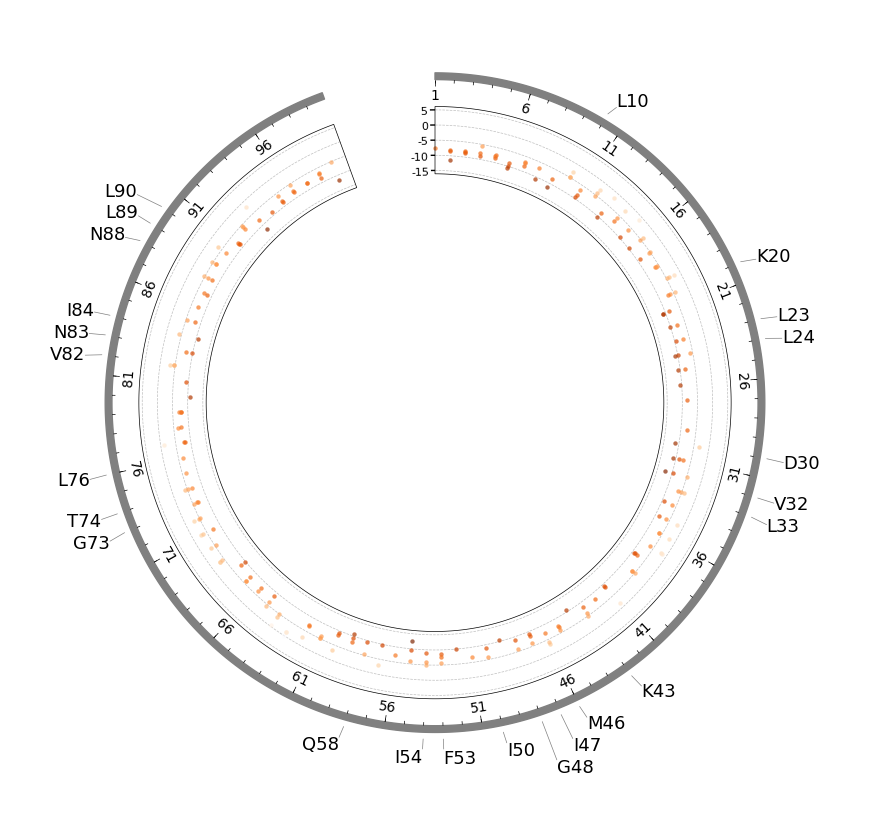

In [105]:
# Add a line track for filtered_delta_e_values
line_track = sector.add_track((68, 88), r_pad_ratio=0.1)
line_track.axis()
# Add scatter plot for delta_e_per_position
# Configure axis and ticks
line_track.yticks(
    [0, 5, 10, 15, 20],  # Positions
    ["-15","-10","-5", "0", "5"],  # Labels
    side="left",
    line_kws=dict(color="black", lw=1),
    text_kws=dict(color="black", size=8)
)

# Add grid lines for the values
line_track.grid(
    y_grid_num=5,  # Number of grid lines
    color="grey",
    lw=0.5,
    ls="--"
)

# # Plot the filtered delta E values as a line
# x_positions = np.arange(1, len(filtered_delta_e_values) + 1)  # X-axis positions
# line_track.line(x_positions, filtered_delta_e_values, lw=1.5, color="blue")

# # Add color-filled areas based on the values
# for i in range(len(filtered_delta_e_values) - 1):
#     x = [x_positions[i], x_positions[i + 1], x_positions[i + 1], x_positions[i]]
#     y = [0, 0, filtered_delta_e_values[i + 1], filtered_delta_e_values[i]]
#     color = "red" if filtered_delta_e_values[i] < 0 else "green"
#     line_track.fill(x, y, fc=color, ec="none", alpha=0.5)

# Plot all the delta E values from filtered_delta_e_dict
# Define the color map for the scatter plot
scatter_cmap_positive = cm.get_cmap("Purples")
scatter_cmap_negative = cm.get_cmap("Oranges_r")
scatter_norm_positive = colors.Normalize(vmin=0, vmax=largest_value)
scatter_norm_negative = colors.Normalize(vmin=smallest_value, vmax=0)

for x_key, y_values in filtered_delta_e_dict.items():
    # Add 15 to each y value and plot it on the grid
    for y_value in y_values:
        if y_value >= 0:
            adjusted_color = scatter_cmap_positive(scatter_norm_positive(y_value))
        else:
            adjusted_color = scatter_cmap_negative(scatter_norm_negative(y_value))
        line_track.scatter([x_key-1], [(y_value + 15)], vmax=20, s=10, color=adjusted_color, alpha=0.7)

fig = circos.plotfig()
plt.show()


with data from delta_delta_e_per_pair, add a track of cytoband (0-40) connect all the positions with delta delta e value >5.5 or dde <2 colored with color scheme PiYG 

use api from this example, code should be different:

from pycirclize import Circos
from pycirclize.utils import ColorCycler, load_eukaryote_example_dataset

# Load hg38 dataset (https://github.com/moshi4/pycirclize-data/tree/main/eukaryote/hg38)
chr_bed_file, cytoband_file, chr_links = load_eukaryote_example_dataset("hg38")

# Initialize Circos from BED chromosomes
circos = Circos.initialize_from_bed(chr_bed_file, space=3)
circos.text("Homo sapiens\n(hg38)", deg=315, r=150, size=12)

# Add cytoband tracks from cytoband file
circos.add_cytoband_tracks((95, 100), cytoband_file)

# Create chromosome color dict
ColorCycler.set_cmap("hsv")
chr_names = [s.name for s in circos.sectors]
colors = ColorCycler.get_color_list(len(chr_names))
chr_name2color = {name: color for name, color in zip(chr_names, colors)}

# Plot chromosome name & xticks
for sector in circos.sectors:
    sector.text(sector.name, r=120, size=10, color=chr_name2color[sector.name])
    sector.get_track("cytoband").xticks_by_interval(
        40000000,
        label_size=8,
        label_orientation="vertical",
        label_formatter=lambda v: f"{v / 1000000:.0f} Mb",
    )

# Plot chromosome link
for link in chr_links:
    region1 = (link.query_chr, link.query_start, link.query_end)
    region2 = (link.ref_chr, link.ref_start, link.ref_end)
    color = chr_name2color[link.query_chr]
    if link.query_chr in ("chr1", "chr8", "chr16") and link.query_chr != link.ref_chr:
        circos.link(region1, region2, color=color)

fig = circos.plotfig()

/var/folders/17/rj19bvws2qscyfjmb7m44zmm0000gn/T/ipykernel_78379/1025708985.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  chord_cmap = cm.get_cmap("bwr_r")


Antagonistic max (min ddE): -3.683882
Synergistic min (max ddE): 4.6108785


Processing DR chords: 100%|██████████| 45/45 [00:00<00:00, 1026.85it/s]


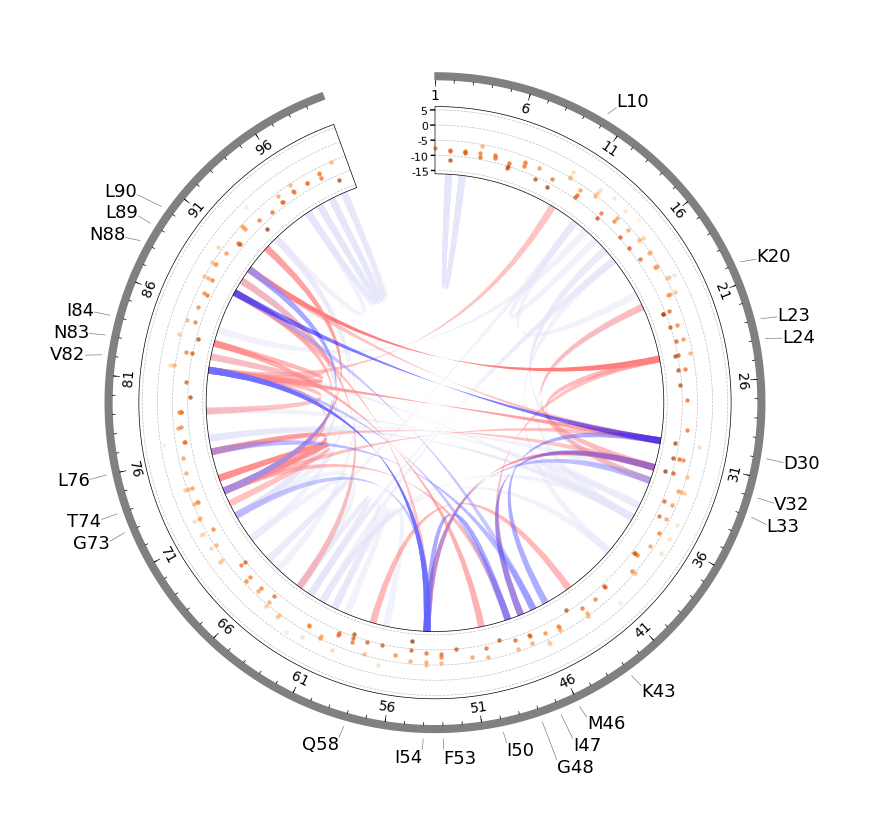

In [106]:
# Add a track for the chords spanning 0-40
# chord_track = sector.add_track((0, 40))
df = pd.read_csv('data/PR_all_100pairs.tsv', sep='\t')
anta_max = df[df['DR_position'] == 1]['ddE'].min()
syner_min = df[df['DR_position'] == 1]['ddE'].max()

print(f"Antagonistic max (min ddE): {anta_max}")
print(f"Synergistic min (max ddE): {syner_min}")
# Define the color map for the chords
chord_cmap = cm.get_cmap("bwr_r")
chord_norm = colors.Normalize(vmin=anta_max, vmax=syner_min)
thickness = 0.5
thickness_d2 = thickness/2
background_thikness = 0.5
background_thickness_d2 = background_thikness/2

##########################background chords for drug resistant positions###############################
# Read the data from the TSV file
df = pd.read_csv('data/PR_all_100pairs.tsv', sep='\t')

# Add a DR_position column based on ddE values
# df['DR_position'] = 0

# Filter for DR_position = 0 (background chords)
background_pairs = df[df['DR_position'] == 0]

# Add background chords
for _, row in tqdm(background_pairs.iterrows(), total=len(background_pairs), desc="Processing background chords"):
    pos1, pos2, dde = row['pos1'], row['pos2'], row['ddE']
    
    # Define regions for the chord
    region1 = ("nl43 ΔΔE", pos1 - background_thickness_d2 - start_aa, pos1 + background_thickness_d2 - start_aa)
    region2 = ("nl43 ΔΔE", pos2 - background_thickness_d2 - start_aa, pos2 + background_thickness_d2 - start_aa)
    
    # Check if the regions are within valid bounds
    if region1[1] < 0 or region1[2] > actual_length or region2[1] < 0 or region2[2] > actual_length:
        continue
    
    # Use light gray color for background
    light_gray_color = "#e6e6fa"
    circos.link(region1, region2, color=light_gray_color)

##########################highlighted chords for drug resistant positions###############################

# Filter for DR_position = 1 (drug resistant pairs)
df = pd.read_csv('data/PR_all_100pairs.tsv', sep='\t')
dr_pairs = df[df['DR_position'] == 1]

# Add drug resistant chords with the same style as background
for _, row in tqdm(dr_pairs.iterrows(), total=len(dr_pairs), desc="Processing DR chords"):
    pos1, pos2, dde = row['pos1'], row['pos2'], row['ddE']
    
    # Define regions for the chord
    region1 = ("nl43 ΔΔE", pos1 - thickness_d2 - start_aa, pos1 + thickness_d2 - start_aa)
    region2 = ("nl43 ΔΔE", pos2 - thickness_d2 - start_aa, pos2 + thickness_d2 - start_aa)
    
    # Check if the regions are within valid bounds
    if region1[1] < 0 or region1[2] > actual_length or region2[1] < 0 or region2[2] > actual_length:
        continue
    
    # Map the delta delta E value to a color using the same colormap as the original selection

    color = chord_cmap(chord_norm(dde))
    
    # Add the chord to the circos plot
    circos.link(region1, region2, color=color, lw=0.01)

# Add a color bar for the chords
chord_mappable = cm.ScalarMappable(norm=chord_norm, cmap=chord_cmap)
fig = circos.plotfig()



add the above negative de and positive de graphs together, but shrik the length of the positive de colormap length by 10 times

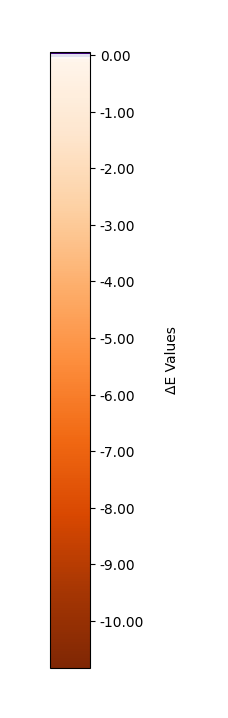

In [107]:
import matplotlib as mpl

# Calculate new data_min and data_max from filtered_delta_e_values
data_min = min(filtered_delta_e_values)
data_max = max(filtered_delta_e_values)

# Add 0.5% padding
padding = 0.005 * (data_max - data_min)
vmin = data_min - padding
vmax = data_max + padding
vcenter = 0

# Define new ticks based on the range
all_ticks = np.arange(np.floor(data_min) + 1, np.ceil(data_max) + 1, 1)  # Ticks from floor(data_min) + 1 to ceil(data_max)

# Build shifted colormap
def shifted_cmap(cmap_neg, cmap_pos, vmin, vmax, vcenter, name="shiftedcmap"):
    """Create a shifted diverging colormap with two different cmaps."""
    midpoint = (vcenter - vmin) / (vmax - vmin)
    cdict = {"red": [], "green": [], "blue": []}

    # Negative side
    reg_index_neg = np.linspace(0, 1, 128, endpoint=False)
    shift_index_neg = np.linspace(0.0, midpoint, 128, endpoint=False)
    for ri, si in zip(reg_index_neg, shift_index_neg):
        r, g, b, _ = cmap_neg(ri)
        cdict["red"].append((si, r, r))
        cdict["green"].append((si, g, g))
        cdict["blue"].append((si, b, b))

    # Positive side
    reg_index_pos = np.linspace(0, 1, 129, endpoint=True)
    shift_index_pos = np.linspace(midpoint, 1.0, 129, endpoint=True)
    for ri, si in zip(reg_index_pos, shift_index_pos):
        r, g, b, _ = cmap_pos(ri)
        cdict["red"].append((si, r, r))
        cdict["green"].append((si, g, g))
        cdict["blue"].append((si, b, b))

    newcmap = mpl.colors.LinearSegmentedColormap(name, cdict)
    return newcmap

cmap = shifted_cmap(plt.cm.Oranges_r, plt.cm.Purples, vmin, vmax, vcenter)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# Plot with vertical orientation and slimmer bar
fig, ax = plt.subplots(figsize=(1, 8))
fig.subplots_adjust(left=0.5)

cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation="vertical")
cb.set_ticks(all_ticks)
cb.set_ticklabels([f"{t:.2f}" for t in all_ticks])

cb.set_label("ΔE Values", rotation=90, labelpad=15)
plt.show()


combine the two above color bar dde and de together, but unify the label sizes, paddings and colormap size



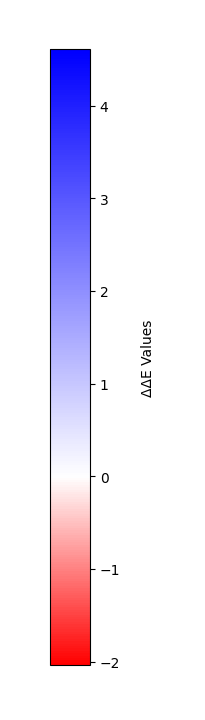

In [ ]:
def shifted_cmap_bwr_vibrant(cmap, vmin, vmax, vcenter, name="shiftedcmap_bwr_vibrant"):
    """Create a shifted diverging colormap using vibrant tones of bwr."""
    midpoint = (vcenter - vmin) / (vmax - vmin)
    cdict = {"red": [], "green": [], "blue": []}

    # Negative side (vibrant tones of bwr)
    reg_index_neg = np.linspace(0, 0.5, 128, endpoint=False)
    shift_index_neg = np.linspace(0.0, midpoint, 128, endpoint=False)
    for ri, si in zip(reg_index_neg, shift_index_neg):
        r, g, b, _ = cmap(ri)
        cdict["red"].append((si, r, r))
        cdict["green"].append((si, g, g))
        cdict["blue"].append((si, b, b))

    # Positive side (vibrant tones of bwr)
    reg_index_pos = np.linspace(0.5, 1, 129, endpoint=True)
    shift_index_pos = np.linspace(midpoint, 1.0, 129, endpoint=True)
    for ri, si in zip(reg_index_pos, shift_index_pos):
        r, g, b, _ = cmap(ri)
        cdict["red"].append((si, r, r))
        cdict["green"].append((si, g, g))
        cdict["blue"].append((si, b, b))

    newcmap = mpl.colors.LinearSegmentedColormap(name, cdict)
    return newcmap


# Define the range for the new colormap
vmin_new = -3.68
vmax_new = 4.61
vcenter_new = 0

# Create the shifted colormap using vibrant tones of bwr
cmap_bwr_vibrant = shifted_cmap_bwr_vibrant(plt.cm.bwr_r, vmin_new, vmax_new, vcenter_new)
norm_bwr_vibrant = mpl.colors.Normalize(vmin=vmin_new, vmax=vmax_new)

# Plot the new colormap
fig, ax = plt.subplots(figsize=(1, 8))
fig.subplots_adjust(left=0.5)
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap_bwr_vibrant, norm=norm_bwr_vibrant, orientation="vertical")
cb.set_label("ΔΔE Values", rotation=90, labelpad=15)
plt.show()